# Intersect-First Zonotope CG Enclosure

This notebook applies the **intersect-first zonotope CG enclosure** to the 300 free coordinates of `system_303`. It preserves the symmetric Jacobi scaling and robust CG-direction selection from `system_303_solver_v3_simplified.ipynb`, runs exactly 520 CG iterations, and evaluates snapshots every 10 iterations.

At each snapshot, the CG information is encoded in

$$
\widehat x_m=c_0+P_mG_m^{-1}P_m^T(b-Ac_0),\qquad
\Pi_m=I-P_mG_m^{-1}P_m^TA,
$$

and the zonotope is $Z_m=\widehat x_m+\Pi_mD_0[-1,1]^n$. The coordinate hull is computed **after intersecting** $Z_m$ with the original box $B_0$. The LP variables are only the zonotope parameters $z$; no accumulated floating-point CG hyperplane equalities are imposed.

The notebook stores every snapshot in `snapshot_results`, exposes stacked analysis arrays, and writes them to `system_303_solver_v6_snapshot_results.npz`.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import qr, solve
from scipy.optimize import linprog


data_dir = Path("system_303")

A_full = np.genfromtxt(data_dir / "stiffness_beam_A.dat", delimiter=",")
b_full = np.genfromtxt(data_dir / "forcing_b.dat")
box = np.genfromtxt(data_dir / "B0_wide_bc.dat", delimiter=",")
x_star_full = np.genfromtxt(data_dir / "soln_x.dat")

# Remove the first three boundary-condition coordinates, as in v3 simplified.
A_original = A_full[3:, 3:]
b_original = b_full[3:]
l0_original = box[3:, 0]
u0_original = box[3:, 1]
x_star = x_star_full[3:]

print(f"system dimension: {len(b_original)}")

system dimension: 300


## Jacobi scaling and experiment controls

With `scale = sqrt(diag(A_original))`, the algorithm is run in the better-scaled coordinates $y=\mathrm{scale}\,x$. Thus `l0`, `u0`, `c0`, `d0`, `x_hat_m`, and `Pi_m` below are in scaled coordinates. Every stored `l_m` and `u_m` is transformed back to the original physical coordinates for analysis.

In [2]:
diagonal = np.diag(A_original)
if np.any(diagonal <= 0):
    raise ValueError("Jacobi scaling requires a positive diagonal.")

scale = np.sqrt(diagonal)
A = A_original / scale[:, None] / scale[None, :]
b = b_original / scale
l0 = scale * l0_original
u0 = scale * u0_original
x_star_scaled = scale * x_star

c0 = 0.5 * (l0 + u0)
d0 = 0.5 * (u0 - l0)
n = len(b)

max_iterations = 520
snapshot_period = 10
snapshot_iterations = np.arange(snapshot_period, max_iterations + 1, snapshot_period)
sanity_atol = 1e-8
sanity_rtol = 1e-10

if np.any(d0 < 0):
    raise ValueError("The initial box has an inverted coordinate interval.")

print(f"CG iterations: {max_iterations}")
print(f"snapshots: {len(snapshot_iterations)} ({snapshot_iterations[0]} through {snapshot_iterations[-1]})")

CG iterations: 520
snapshots: 52 (10 through 520)


## Fixed-iteration CG and robust direction selection

The following functions are retained from the simplified notebook. CG records all 520 search directions. At each prefix, the directions are A-normalized, pivoted QR selects a numerical basis, and the basis is shortened if needed until its projected Gram matrix has condition number at most $10^{12}$.

In [3]:
def conjugate_gradient_directions(A, b, x0, iterations):
    """Run exactly `iterations` CG steps and return all search directions."""
    x = np.array(x0, dtype=float, copy=True)
    r = b - A @ x
    p = r.copy()
    directions = []

    for k in range(iterations):
        Ap = A @ p
        rr = float(r @ r)
        denominator = float(p @ Ap)
        if denominator <= 0 or not np.isfinite(denominator):
            raise RuntimeError(f"Invalid CG denominator at iteration {k}.")

        alpha = rr / denominator
        x = x + alpha * p
        r_next = r - alpha * Ap
        directions.append(p.copy())

        if k < iterations - 1:
            beta = float(r_next @ r_next) / rr
            p = r_next + beta * p
        r = r_next

    return x, np.column_stack(directions)


def select_independent_directions(P_all, A, qr_tolerance=1e-10):
    """A-normalize recorded directions and retain a stable pivoted-QR basis."""
    AP_all = A @ P_all
    a_norm_squared = np.sum(P_all * AP_all, axis=0)
    valid = np.isfinite(a_norm_squared) & (a_norm_squared > 0)
    if not np.any(valid):
        raise RuntimeError("CG produced no direction with a positive A-norm.")

    Q = P_all[:, valid] / np.sqrt(a_norm_squared[valid])[None, :]
    _, R, pivots = qr(Q, mode="economic", pivoting=True)
    diagonal = np.abs(np.diag(R))
    candidate_rank = int(np.sum(diagonal > qr_tolerance * diagonal[0]))
    if candidate_rank == 0:
        raise RuntimeError("The recorded CG directions are numerically rank zero.")

    # Retain the largest QR basis whose projected Gram solve is stable.
    for rank in range(candidate_rank, 0, -1):
        P = Q[:, pivots[:rank]]
        G = P.T @ A @ P
        if np.linalg.cond(G) <= 1e12:
            return P

    raise RuntimeError("No numerically stable independent direction set was found.")

## Intersect-first coordinate hull

For one snapshot, `build_zonotope` uses linear solves rather than explicitly forming $G_m^{-1}$. The efficient generator expression

```python
M = Pi_m * d0[None, :]
```

forms $\Pi_mD_0$ without constructing the diagonal matrix $D_0$.

`intersect_first_hull` first checks feasibility and then reuses the same intersection constraints and variable bounds for all $2n$ extrema. Its timer begins immediately before the feasibility LP and ends immediately after the last coordinate bound is recovered.

In [4]:
def build_zonotope(A, b, c0, d0, P_all):
    """Return the selected basis, x_hat, Pi, and M = Pi D0."""
    P_m = select_independent_directions(P_all, A)
    G_m = P_m.T @ A @ P_m

    coefficients = solve(G_m, P_m.T @ (b - A @ c0), assume_a="sym")
    x_hat_m = c0 + P_m @ coefficients

    # Solve G_m X = P_m.T A instead of explicitly forming G_m^{-1}.
    solved_PTA = solve(G_m, P_m.T @ A, assume_a="sym")
    Pi_m = np.eye(len(b)) - P_m @ solved_PTA

    # Efficient column scaling; do not explicitly construct D0 = diag(d0).
    M = Pi_m * d0[None, :]
    return P_m, G_m, x_hat_m, Pi_m, M


def intersect_first_hull(M, x_hat_m, l0, u0, snapshot_m):
    """Compute hull((x_hat_m + M[-1,1]^n) intersection B0)."""
    n = M.shape[1]
    A_ub = np.vstack((M, -M))
    b_ub = np.concatenate((u0 - x_hat_m, x_hat_m - l0))
    bounds = [(-1.0, 1.0)] * n

    l_m = np.empty(n)
    u_m = np.empty(n)
    min_status = np.empty(n, dtype=int)
    max_status = np.empty(n, dtype=int)
    min_configuration = np.empty(n, dtype=object)
    max_configuration = np.empty(n, dtype=object)
    non_success_attempts = []

    # Some numerically difficult objectives can return HiGHS model status
    # "Unknown" under one option set and solve optimally under another. Every
    # attempt still uses method="highs"; any non-success is reported immediately
    # and retained in solver_status rather than being silently ignored.
    highs_configurations = [
        ("default", None),
        (
            "tight_feasibility",
            {
                "primal_feasibility_tolerance": 1e-9,
                "dual_feasibility_tolerance": 1e-9,
            },
        ),
        ("no_presolve", {"presolve": False}),
        (
            "no_presolve_tight_feasibility",
            {
                "presolve": False,
                "primal_feasibility_tolerance": 1e-9,
                "dual_feasibility_tolerance": 1e-9,
            },
        ),
    ]

    def solve_with_diagnostics(objective, stage, coordinate=None):
        for attempt, (configuration, options) in enumerate(highs_configurations, start=1):
            result = linprog(
                objective,
                A_ub=A_ub,
                b_ub=b_ub,
                bounds=bounds,
                method="highs",
                options=options,
            )
            if result.success:
                if attempt > 1:
                    print(
                        f"  LP recovered at snapshot m={snapshot_m}, stage={stage}, "
                        f"coordinate={coordinate}, configuration={configuration}",
                        flush=True,
                    )
                return result, configuration

            diagnostic = {
                "stage": stage,
                "coordinate": coordinate,
                "configuration": configuration,
                "status": int(result.status),
                "message": str(result.message),
            }
            non_success_attempts.append(diagnostic)
            elapsed = perf_counter() - optimization_start
            print(
                f"LP NON-SUCCESS at snapshot m={snapshot_m}, stage={stage}, "
                f"coordinate={coordinate}, configuration={configuration}: "
                f"status={result.status}, message={result.message!r}, "
                f"elapsed={elapsed:.3f} s",
                flush=True,
            )

        raise RuntimeError(
            f"All HiGHS configurations failed at snapshot m={snapshot_m}, "
            f"stage={stage}, coordinate={coordinate}."
        )

    # Only feasibility plus coordinate optimization belongs in this timing.
    optimization_start = perf_counter()
    feasibility, feasibility_configuration = solve_with_diagnostics(
        np.zeros(n), stage="feasibility"
    )

    for i in range(n):
        min_result, min_configuration[i] = solve_with_diagnostics(
            M[i, :], stage="minimum", coordinate=i
        )
        min_status[i] = min_result.status
        max_result, max_configuration[i] = solve_with_diagnostics(
            -M[i, :], stage="maximum", coordinate=i
        )
        max_status[i] = max_result.status

        l_m[i] = x_hat_m[i] + min_result.fun
        u_m[i] = x_hat_m[i] - max_result.fun

    optimization_time = perf_counter() - optimization_start
    solver_status = {
        "feasibility_success": bool(feasibility.success),
        "feasibility_status": int(feasibility.status),
        "feasibility_message": str(feasibility.message),
        "feasibility_configuration": feasibility_configuration,
        "min_status": min_status,
        "max_status": max_status,
        "min_configuration": min_configuration,
        "max_configuration": max_configuration,
        "non_success_attempts": non_success_attempts,
        "all_extrema_success": bool(np.all(min_status == 0) and np.all(max_status == 0)),
    }
    return l_m, u_m, optimization_time, solver_status

## Run all 52 snapshots

In [5]:
x_cg, P_all = conjugate_gradient_directions(
    A=A,
    b=b,
    x0=c0,
    iterations=max_iterations,
)

snapshot_results = []
initial_width = u0_original - l0_original

for m in snapshot_iterations:
    # CG, basis selection, Gram solves, and generator construction are untimed.
    P_m, G_m, x_hat_m, Pi_m, M = build_zonotope(
        A=A,
        b=b,
        c0=c0,
        d0=d0,
        P_all=P_all[:, :m],
    )

    l_m_scaled, u_m_scaled, optimization_time, solver_status = intersect_first_hull(
        M=M,
        x_hat_m=x_hat_m,
        l0=l0,
        u0=u0,
        snapshot_m=int(m),
    )

    # Convert the enclosure to the original physical coordinates after timing.
    l_m = l_m_scaled / scale
    u_m = u_m_scaled / scale
    widths = u_m - l_m
    with np.errstate(divide="ignore", invalid="ignore"):
        contraction = 100.0 * (1.0 - widths / initial_width)

    finite_contraction = contraction[np.isfinite(contraction)]
    reference_scale = max(
        1.0,
        float(np.max(np.abs(l_m))),
        float(np.max(np.abs(u_m))),
        float(np.max(np.abs(x_star))),
    )
    sanity_tolerance = sanity_atol + sanity_rtol * reference_scale
    order_violation = max(0.0, float(np.max(l_m - u_m)))
    containment_violation = max(
        0.0,
        float(np.max(l_m - x_star)),
        float(np.max(x_star - u_m)),
    )
    order_ok = order_violation <= sanity_tolerance
    contains_x_star = containment_violation <= sanity_tolerance

    result = {
        "m": int(m),
        "rank": int(P_m.shape[1]),
        "l_m": l_m.copy(),
        "u_m": u_m.copy(),
        "l_m_scaled": l_m_scaled.copy(),
        "u_m_scaled": u_m_scaled.copy(),
        "optimization_time": float(optimization_time),
        "feasibility_success": solver_status["feasibility_success"],
        "feasibility_status": solver_status["feasibility_status"],
        "feasibility_message": solver_status["feasibility_message"],
        "solver_status": solver_status,
        "non_success_attempt_count": len(solver_status["non_success_attempts"]),
        "width_min": float(np.min(widths)),
        "width_mean": float(np.mean(widths)),
        "width_max": float(np.max(widths)),
        "contraction_min_pct": float(np.min(finite_contraction)),
        "contraction_mean_pct": float(np.mean(finite_contraction)),
        "contraction_median_pct": float(np.median(finite_contraction)),
        "contraction_max_pct": float(np.max(finite_contraction)),
        "order_ok": bool(order_ok),
        "contains_x_star": bool(contains_x_star),
        "max_order_violation": float(order_violation),
        "max_x_star_violation": float(containment_violation),
        "sanity_tolerance": float(sanity_tolerance),
    }
    snapshot_results.append(result)

    print(
        f"Snapshot m={m}: rank(P)={P_m.shape[1]}, "
        f"optimization time = {optimization_time:.2f} s",
        flush=True,
    )
    print(
        f"  width min/mean/max = {widths.min():.6e} / {widths.mean():.6e} / "
        f"{widths.max():.6e}; contraction min/mean/median/max = "
        f"{finite_contraction.min():.2f}% / {finite_contraction.mean():.2f}% / "
        f"{np.median(finite_contraction):.2f}% / {finite_contraction.max():.2f}%",
        flush=True,
    )
    if not order_ok:
        print(
            f"  SANITY CHECK FAILED: l_m <= u_m; maximum violation = "
            f"{order_violation:.6e} (tolerance {sanity_tolerance:.6e})",
            flush=True,
        )
    if not contains_x_star:
        print(
            f"  SANITY CHECK FAILED: x_star containment; maximum violation = "
            f"{containment_violation:.6e} (tolerance {sanity_tolerance:.6e})",
            flush=True,
        )

print(f"Completed {len(snapshot_results)} snapshots.")

Snapshot m=10: rank(P)=10, optimization time = 14.47 s


  width min/mean/max = 1.564869e-01 / 1.779106e+00 / 5.000000e+00; contraction min/mean/median/max = -0.00% / 1.08% / 0.00% / 96.87%


LP NON-SUCCESS at snapshot m=20, stage=minimum, coordinate=52, configuration=default: status=4, message='The HiGHS status code was not recognized. (HiGHS Status 15: model_status is Unknown; primal_status is Basic)', elapsed=24.604 s


  LP recovered at snapshot m=20, stage=minimum, coordinate=52, configuration=tight_feasibility


LP NON-SUCCESS at snapshot m=20, stage=minimum, coordinate=148, configuration=default: status=4, message='The HiGHS status code was not recognized. (HiGHS Status 15: model_status is Unknown; primal_status is Basic)', elapsed=35.542 s


...

Snapshot m=510: rank(P)=200, optimization time = 5.34 s


  width min/mean/max = 3.046983e-07 / 6.745383e-02 / 2.000000e-01; contraction min/mean/median/max = -0.00% / 66.63% / 99.92% / 100.00%


Snapshot m=520: rank(P)=200, optimization time = 5.52 s


  width min/mean/max = 1.941531e-08 / 6.671684e-02 / 2.000000e-01; contraction min/mean/median/max = -0.00% / 66.66% / 99.99% / 100.00%


Completed 52 snapshots.


## Expose and save snapshot arrays

`snapshot_results` retains detailed dictionaries, including LP statuses and numerical diagnostics. The following stacked arrays provide a convenient compact representation and are also saved to disk.

In [6]:
snapshot_ranks = np.array([result["rank"] for result in snapshot_results])
optimization_times = np.array([result["optimization_time"] for result in snapshot_results])
l_history = np.stack([result["l_m"] for result in snapshot_results])
u_history = np.stack([result["u_m"] for result in snapshot_results])
width_history = u_history - l_history
with np.errstate(divide="ignore", invalid="ignore"):
    contraction_history = 100.0 * (
        1.0 - width_history / initial_width[None, :]
    )

feasibility_statuses = np.array(
    [result["feasibility_status"] for result in snapshot_results], dtype=int
)
non_success_attempt_counts = np.array(
    [result["non_success_attempt_count"] for result in snapshot_results], dtype=int
)
order_violations = np.array(
    [result["max_order_violation"] for result in snapshot_results]
)
x_star_violations = np.array(
    [result["max_x_star_violation"] for result in snapshot_results]
)

results_path = Path("system_303_solver_v6_snapshot_results.npz")
np.savez_compressed(
    results_path,
    m=snapshot_iterations,
    rank=snapshot_ranks,
    l_m=l_history,
    u_m=u_history,
    optimization_time=optimization_times,
    feasibility_status=feasibility_statuses,
    non_success_attempt_count=non_success_attempt_counts,
    contraction_pct=contraction_history,
    max_order_violation=order_violations,
    max_x_star_violation=x_star_violations,
)

print(f"saved snapshot arrays to: {results_path}")
print(f"all interval-order checks passed: {all(r['order_ok'] for r in snapshot_results)}")
print(f"x_star is in every enclosure: {all(r['contains_x_star'] for r in snapshot_results)}")
print(f"maximum interval-order violation: {order_violations.max():.6e}")
print(f"maximum x_star containment violation: {x_star_violations.max():.6e}")

saved snapshot arrays to: system_303_solver_v6_snapshot_results.npz
all interval-order checks passed: True
x_star is in every enclosure: True
maximum interval-order violation: 0.000000e+00
maximum x_star containment violation: 0.000000e+00


## Optimization cost

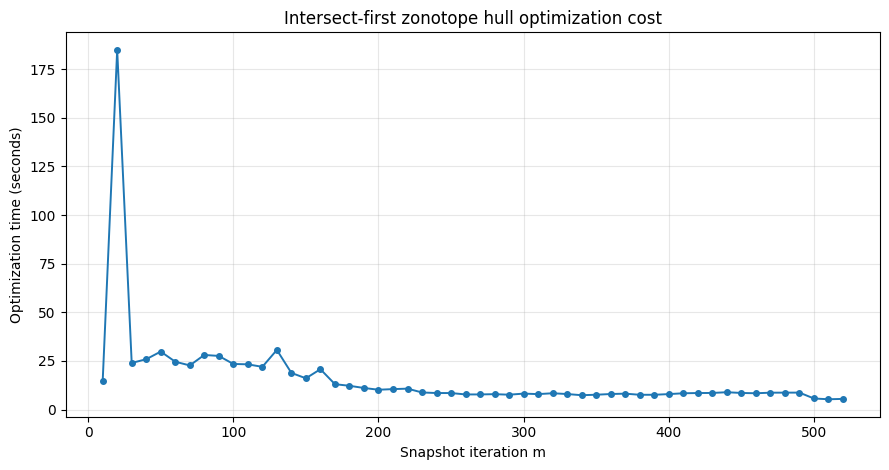

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(snapshot_iterations, optimization_times, marker="o", markersize=4, linewidth=1.4)
ax.set_xlabel("Snapshot iteration m")
ax.set_ylabel("Optimization time (seconds)")
ax.set_title("Intersect-first zonotope hull optimization cost")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Enclosure and contraction summaries

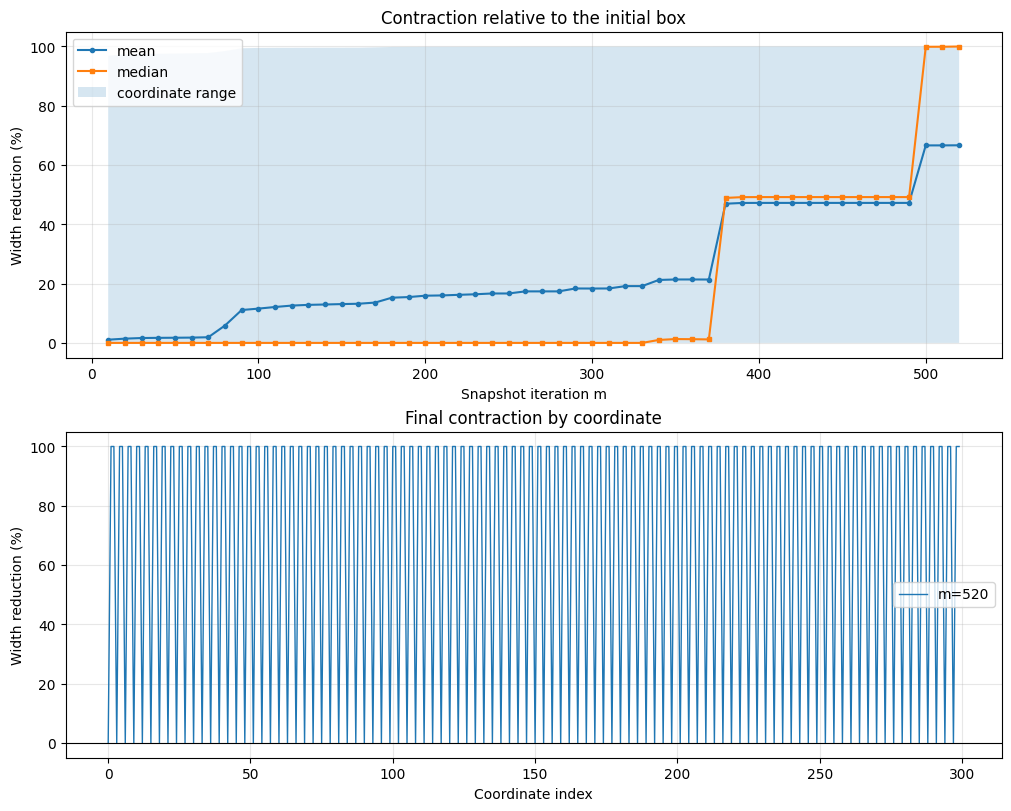

In [8]:
finite_contraction = np.where(np.isfinite(contraction_history), contraction_history, np.nan)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True)

axes[0].plot(
    snapshot_iterations,
    np.nanmean(finite_contraction, axis=1),
    marker="o",
    markersize=3,
    label="mean",
)
axes[0].plot(
    snapshot_iterations,
    np.nanmedian(finite_contraction, axis=1),
    marker="s",
    markersize=3,
    label="median",
)
axes[0].fill_between(
    snapshot_iterations,
    np.nanmin(finite_contraction, axis=1),
    np.nanmax(finite_contraction, axis=1),
    alpha=0.18,
    label="coordinate range",
)
axes[0].set_xlabel("Snapshot iteration m")
axes[0].set_ylabel("Width reduction (%)")
axes[0].set_title("Contraction relative to the initial box")
axes[0].grid(alpha=0.3)
axes[0].legend()

coordinate_indices = np.arange(n)
axes[1].plot(
    coordinate_indices,
    finite_contraction[-1],
    linewidth=1,
    label=f"m={snapshot_iterations[-1]}",
)
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set_xlabel("Coordinate index")
axes[1].set_ylabel("Width reduction (%)")
axes[1].set_title("Final contraction by coordinate")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.show()

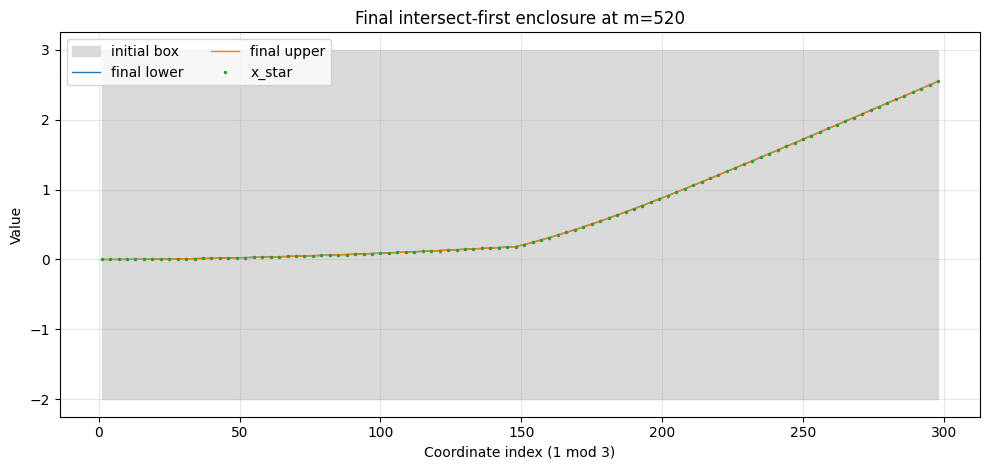

In [9]:
mod1_indices = np.arange(n)[np.arange(n) % 3 == 1]

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.fill_between(
    mod1_indices,
    l0_original[mod1_indices],
    u0_original[mod1_indices],
    color="0.85",
    label="initial box",
)
ax.plot(mod1_indices, l_history[-1, mod1_indices], linewidth=1, label="final lower")
ax.plot(mod1_indices, u_history[-1, mod1_indices], linewidth=1, label="final upper")
ax.plot(mod1_indices, x_star[mod1_indices], ".", markersize=3, label="x_star")
ax.set_xlabel("Coordinate index (1 mod 3)")
ax.set_ylabel("Value")
ax.set_title(f"Final intersect-first enclosure at m={snapshot_iterations[-1]}")
ax.grid(alpha=0.3)
ax.legend(ncol=2)
fig.tight_layout()
plt.show()